# 3. nedēļa: Klasifikācija
## Modeļu trenēšana, validācija un salīdzināšana

## 1. uzdevums. Sagatavo datus modelēšanai

### 1.1. Ielādē tīro datu kopu

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../week2/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
df.head()

Datu kopa: 12330 rindas, 28 kolonnas


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,TotalDuration
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,0,0,0,0,0,0,0,0,1,-1.326469
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,...,0,0,0,0,0,0,0,0,1,-1.293024
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,0,0,0,0,0,0,0,0,1,-1.326469
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,-0.308821,...,0,0,0,0,0,0,0,0,1,-1.325076
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,-0.308821,...,0,0,0,0,0,0,0,0,1,-0.998552


### 1.2. Definē X un y

In [18]:
# Target mainīgais — vai klients veica pirkumu
y = df['Revenue']

# Features — visas pārējās kolonnas
X = df.drop('Revenue', axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target sadalījums:\n{y.value_counts()}")
print(f"\nPirkumu īpatsvars: {y.mean():.1%}")

Features skaits: 27
Target sadalījums:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Pirkumu īpatsvars: 15.5%


### 1.3. Sadali datos treniņa un testa kopās

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa:   {X_test.shape[0]} rindas")
print(f"\nTarget sadalījums treniņa kopā:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nTarget sadalījums testa kopā:")
print(y_test.value_counts(normalize=True).round(3))

Treniņa kopa: 9864 rindas
Testa kopa:   2466 rindas

Target sadalījums treniņa kopā:
Revenue
0    0.845
1    0.155
Name: proportion, dtype: float64

Target sadalījums testa kopā:
Revenue
0    0.845
1    0.155
Name: proportion, dtype: float64


### Kāpēc stratify=y un sadalījums 80/20?

stratify=y nodrošina, ka treniņa un testa kopās saglabājas vienāds pirkumu īpatsvars.  
Bez stratify varētu gadīties, ka testa kopā ir pārāk maz vai pārāk daudz pirkumu, un modeļa novērtējums būtu maldinošs.

**80/20 sadalījums** ir klasiska pieeja: 80% datu lieto modeļa trenēšanai, 20% - neatkarīgai pārbaudei.  
Mazāka testa kopa (piemēram, 90/10) dod mazāk uzticamu novērtējumu; lielāka testa kopa (piemēram, 70/30) atstāj mazāk datu trenēšanai.

---
## 2. uzdevums. Trenē pirmo modeli — Decision Tree

### 2.1. Uztrenē Decision Tree klasifikatoru

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Izveido un uztrenē modeli
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Prognozes uz testa kopas
dt_pred = dt_model.predict(X_test)

print("=== Decision Tree rezultāti ===")
print(classification_report(y_test, dt_pred))

=== Decision Tree rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.73      0.56      0.63       382

    accuracy                           0.90      2466
   macro avg       0.82      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466



### 2.2. Confusion Matrix

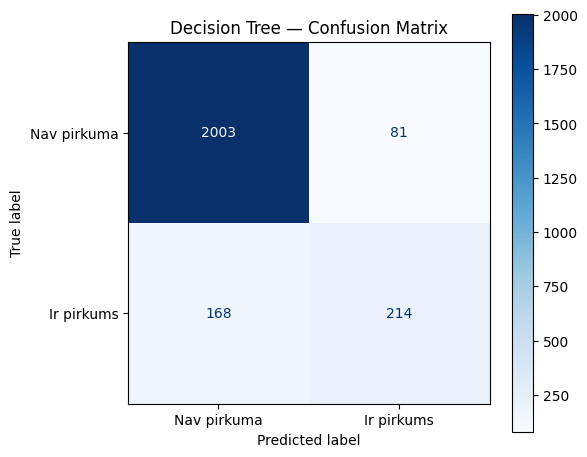

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Blues', ax=ax
)
ax.set_title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()

### 2.3. Pārbaudi overfitting (train vs test)

In [22]:
from sklearn.metrics import accuracy_score, f1_score

dt_train_pred = dt_model.predict(X_train)

print(f"Train accuracy: {accuracy_score(y_train, dt_train_pred):.3f}")
print(f"Test  accuracy: {accuracy_score(y_test,  dt_pred):.3f}")
print(f"\nTrain F1: {f1_score(y_train, dt_train_pred):.3f}")
print(f"Test  F1: {f1_score(y_test,  dt_pred):.3f}")

Train accuracy: 0.912
Test  accuracy: 0.899

Train F1: 0.683
Test  F1: 0.632


### 2.4. Rezultātu interpretācija

**Confusion Matrix (testa kopa: 2466 klienti):**
- TN = 2003 — pareizi prognozēts "nav pirkuma"
- FP = 81 — teikts "pirks", bet nepirka (velti iztērēta atlaide)
- FN = 168 — teikts "nepirks", bet pirka (pazaudēts pircējs)
- TP = 214 — pareizi prognozēts "ir pirkums"

**Precizitāte:** precision = 73%, recall = 56%, F1 = 0.632

**FP un FN biznesa nozīme:**
- **FP** -> nosūtījām atlaidi klientam, kurš nepirka - iztērēts mārketinga budžets.
- **FN** -> nenosūtījām atlaidi klientam, kurš gribēja pirkt - zaudēts potenciāls pircējs.

FN ir sāpīgāks: zaudēts reāls pircējs izmaksā vairāk nekā velti izsūtīta atlaide. Tāpēc svarīgi tiekties uz augstu Recall.

**Overfitting:** Train F1 = 0.683, Test F1 = 0.632 — neliela starpība, modelis nav ievērojami pārmācījies.

---
## 3. uzdevums. Trenē otro modeli — Random Forest

### 3.1. Uztrenē Random Forest klasifikatoru

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Izveido un uztrenē modeli
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Prognozes uz testa kopas
rf_pred = rf_model.predict(X_test)

print("=== Random Forest rezultāti ===")
print(classification_report(y_test, rf_pred))

=== Random Forest rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2084
           1       0.76      0.55      0.64       382

    accuracy                           0.90      2466
   macro avg       0.84      0.76      0.79      2466
weighted avg       0.90      0.90      0.90      2466



### 3.2. Confusion Matrix

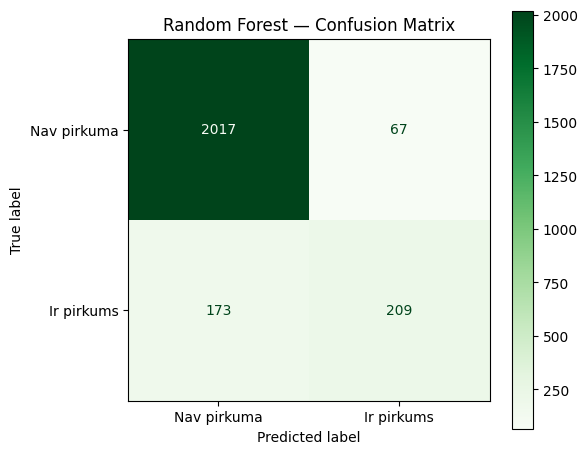

In [24]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Greens', ax=ax
)
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

### 3.3. Rezultātu interpretācija

**Confusion Matrix (testa kopa: 2466 klienti):**
- TN = 2017, FP = 67, FN = 173, TP = 209

**Precizitāte:** precision = 76%, recall = 55%, F1 = 0.635

Salīdzinot ar Decision Tree: FP samazinājās no 81 → 67, FN nedaudz pieauga (168 → 173). Random Forest ir precīzāks - retāk tērē budžetu velti. F1 praktiski vienāds (0.635 vs 0.632).

---
## 4. uzdevums. Trenē trešo modeli — Logistic Regression

### 4.1. Uztrenē Logistic Regression klasifikatoru

In [25]:
from sklearn.linear_model import LogisticRegression

# Izveido un uztrenē modeli
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Prognozes uz testa kopas
lr_pred = lr_model.predict(X_test)

print("=== Logistic Regression rezultāti ===")
print(classification_report(y_test, lr_pred))

=== Logistic Regression rezultāti ===
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.75      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



### 4.2. Varbūtību analīze

Logistic Regression unikālā priekšrocība — tā dabiskā veidā dod varbūtības:

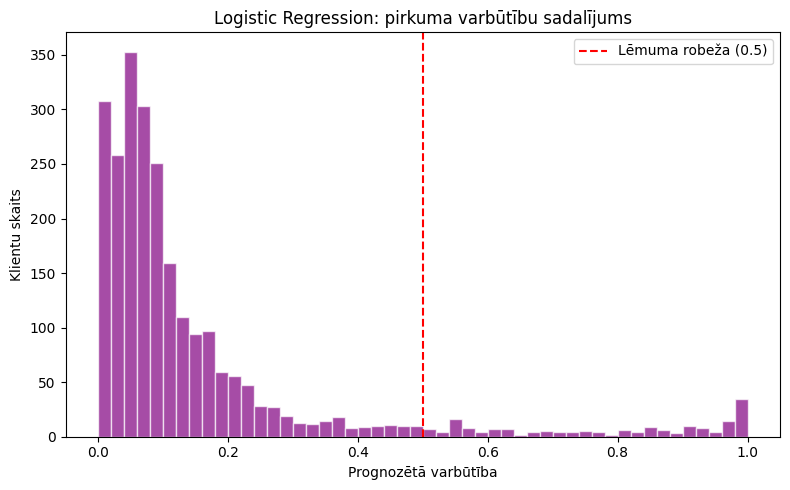

Vidējā prognozētā varbūtība: 0.153
Klientu skaits ar varbūtību > 0.5: 182


In [26]:
# Varbūtības katram klientam
lr_proba = lr_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 5))
plt.hist(lr_proba, bins=50, color='purple', edgecolor='white', alpha=0.7)
plt.axvline(x=0.5, color='red', linestyle='--', label='Lēmuma robeža (0.5)')
plt.title('Logistic Regression: pirkuma varbūtību sadalījums')
plt.xlabel('Prognozētā varbūtība')
plt.ylabel('Klientu skaits')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Vidējā prognozētā varbūtība: {lr_proba.mean():.3f}")
print(f"Klientu skaits ar varbūtību > 0.5: {(lr_proba > 0.5).sum()}")

### 4.3. Confusion Matrix

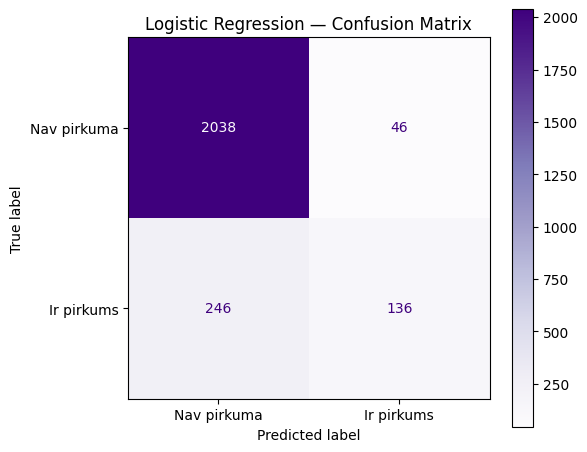

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Purples', ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

### 4.4. Rezultātu interpretācija

**Confusion Matrix (testa kopa: 2466 klienti):**
- TN = 2038, FP = 46, FN = 246, TP = 136

**Precizitāte:** precision = 75%, recall = 36%, F1 = 0.482

Mazākais FP skaits (46) - modelis reti prognozē pirkumu kļūdaini. Taču recall ir zemākais (36%) - 246 no 382 pircējiem palika neatklāti. Varbūtību histogramma parāda, kāda ir katra klienta pirkuma iespējamība, ko var izmantot prioritizēšanai.

---
## 5. uzdevums. Salīdzini modeļus

### 5.1. F1 score salīdzinājums

In [28]:
dt_f1 = f1_score(y_test, dt_pred)
rf_f1 = f1_score(y_test, rf_pred)
lr_f1 = f1_score(y_test, lr_pred)

results = pd.DataFrame({
    'Modelis': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'F1 Score': [dt_f1, rf_f1, lr_f1]
})
print(results.to_string(index=False))

            Modelis  F1 Score
      Decision Tree  0.632201
      Random Forest  0.635258
Logistic Regression  0.482270


### 5.2. Vizuāls salīdzinājums — visas trīs confusion matrices

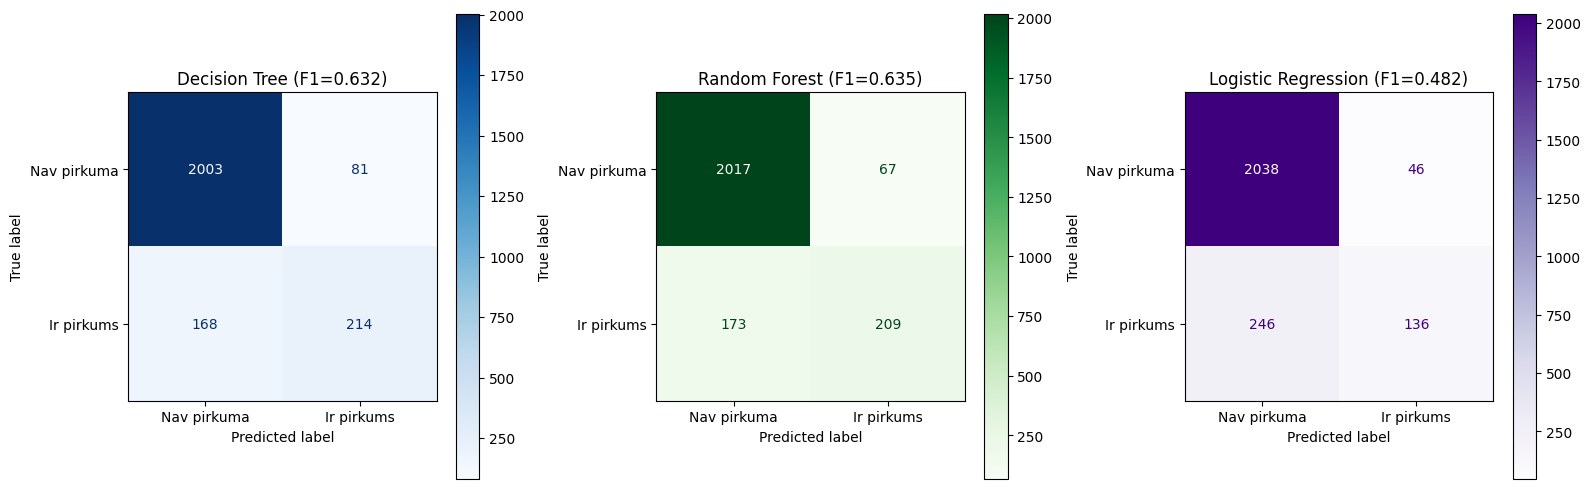

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Decision Tree (F1={dt_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title(f'Random Forest (F1={rf_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Purples', ax=axes[2]
)
axes[2].set_title(f'Logistic Regression (F1={lr_f1:.3f})')

plt.tight_layout()
plt.show()

### 5.3. Feature Importance — kuras iezīmes visvairāk ietekmē pirkumu?

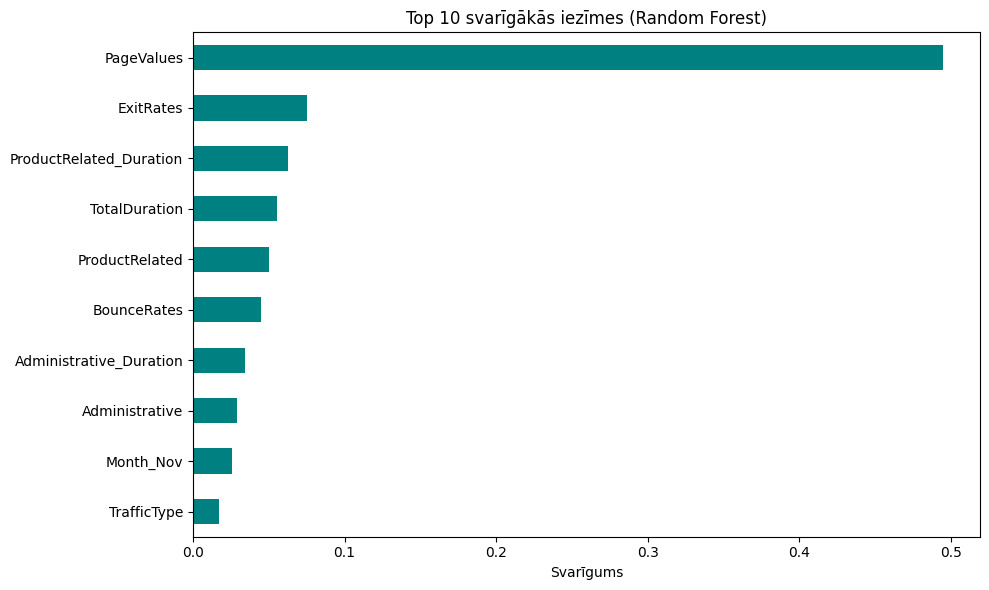

Top 5 svarīgākās iezīmes:
PageValues                 0.4946
ExitRates                  0.0752
ProductRelated_Duration    0.0627
TotalDuration              0.0554
ProductRelated             0.0504
dtype: float64


In [30]:
# Kuras iezīmes visvairāk ietekmē prognozi?
importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās iezīmes (Random Forest)')
plt.xlabel('Svarīgums')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 svarīgākās iezīmes:")
print(feat_imp.head(5).round(4))

### 5.4. Secinājumi

Random Forest ir labākais pēc F1 (0.635), lai gan starpība ar Decision Tree ir minimāla. Logistic Regression un KNN atpaliek ievērojami.

F1 ir piemērotāks rādītājs nekā accuracy, jo modelis, kas vienmēr saka "nepirks", sasniegtu ~84.5% accuracy, bet F1 = 0.

Svarīgākās iezīmes: `PageValues` (49.5%), `ExitRates` (7.5%), `ProductRelated_Duration` (6.3%) — `PageValues` dominē ar lielu pārsvaru.